<center><h1 style="font-size:2em;color:RED">ANÁLISIS DE DATOS CON ALGORITMOS DE MACHINE LEARNING PARA EL ANÁLISIS DE SENTIMIENTOS EN FEEDBACKS DE USUARIOS</h1></center>

**Objetivo:** Desarrollar y evaluar modelos de Machine Learning para clasificar automáticamente comentarios de clientes (Positivo/Negativo) y generar una probabilidad de confianza.

**Contexto:** Este modelo será serializado e integrado en una arquitectura de microservicios, donde una API REST consumirá las predicciones para priorizar la atención al cliente.

**Dataset:** IMDB Reviews (50k registros).

![banner_diabetes](https://drive.google.com/uc?id=1pCmyd5FrtO19iPTKVR75hM8_sJJ6y-tt)

**Realizado por:**
* **Yazmani Reyes Hernandez**
* **Javiera Pulgar**
* **Mauricio Flores**
* **Leandro Diaz**
* **Domingo Galaz**
* **Fernanda Fonseca**

En el presente trabajo se realiza un proyecto de principio a fin, asumiendo el rol de un científico de datos recientemente contratado por una empresa, con el objetivo de determinar el sentimiento que tiene un cliente en el momento de compartir su feedback en un comentario en alguna plataforma online de compras y/o servicios, esto a través del analisis de datos y el uso de algoritmos de Machine Learning. Estos son los pasos principales a seguir:

* Instalación de Librerías y Configuración
* Carga de Datos (Robusta)
* Exploración y limpieza de los datos (EDA)
* Limpieza y Preprocesamiento (Lematización)
* Transformación de los textos en números con TF-IDF y División de Datos
* Entrenamiento de los Modelos Supervisados, Metricas de Desempeño (Accuracy, Precision, Recall, F1-Score) y seleccion final de un modelo
* Justificación Técnica de la Selección del Modelo
* Función de Predicción Avanzada (El motor de nuestra App)
* ¡Probamos la App!
* Serialización del Modelo Final (Guardar para el Backend)

## Observar el panorama general y entiender el problema.

<center><h1 style="font-size:1.5em;color:#2467C0">Caso de estudio: Análisis de Sentimientos</h1></center>  

![sentiment1](https://drive.google.com/uc?id=1jJ9sbBaFhT2rlEyoGdxE3klV7Hnf_0Pz)

**Descripción del proyecto**

Crear una API simple que recibe textos (comentarios, reseñas o tweets), aplica un modelo de Data Science para clasificar el sentimiento (Atrasado / Puntual → en este caso binario: Positivo / Negativo) y devuelve el resultado en formato JSON, permitiendo que las aplicaciones consuman esta predicción automáticamente.

**Necesidad del cliente (explicación no técnica)**

Un cliente (empresa) recibe muchos comentarios y no puede leerlos todos manualmente. Quiere:
* Saber rápidamente si los clientes se están quejando o elogiando;
* Priorizar respuestas a comentarios negativos;
* Medir la satisfacción a lo largo del tiempo.
* Este proyecto ofrece una solución automática para clasificar mensajes y generar información accionable.

# Instalación de Librerías y Configuración

Aquí instalamos herramientas que no vienen por defecto en Colab, específicamente deep-translator para cumplir con el requisito de traducir el texto y joblib para guardar el modelo. También configuramos los gráficos para que se vean mas interesantes.


In [1]:
# Instalar librería para traducción (necesaria para la función final de la API)
!pip install -q deep-translator

# Importación de librerías estándar
import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from deep_translator import GoogleTranslator

# Librerías de Procesamiento de Lenguaje Natural (NLP)
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Librerías de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.4 MB/s eta 0:00:00


In [2]:
# Configuración de descargas de NLTK (Diccionarios de palabras)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
# Estilo de gráficos
sns.set_style("whitegrid")
print("✅ Entorno configurado y librerías listas.")

✅ Entorno configurado y librerías listas.


# Carga de Datos (Robusta)

Intentaremos cargar desde Google Drive (por dafult), pero si falla, usaremos una URL pública para que el código no se rompa si cambiamos el archivo de lugar.

In [4]:
from google.colab import drive
import os

# Intentamos montar Drive
try:
    drive.mount('/content/drive')
    # RUTA: Ajusta esta ruta si tu archivo está en otra carpeta de tu Drive
    ruta_archivo = '/content/drive/MyDrive/No Country/Proyecto - No Country - Análisis de Sentimientos/IMDB Dataset.csv'

    if os.path.exists(ruta_archivo):
        df = pd.read_csv(ruta_archivo)
        print("✅ Dataset cargado desde Google Drive.")
    else:
        raise FileNotFoundError("Archivo no encontrado en la ruta especificada.")

except Exception as e:
    print(f"⚠️ No se pudo cargar desde Drive: {e}")
    print("🔄 Intentando carga desde URL de respaldo...")
    # URL pública del dataset IMDB (backup)
    url_backup = "https://raw.githubusercontent.com/laxmimerit/IMDB-Movie-Reviews-Large-Dataset-50k/master/train.csv"
    try:
        df = pd.read_csv(url_backup)
        # Ajuste de nombres de columnas si vienen diferentes en el backup
        if 'Review' in df.columns: df.rename(columns={'Review': 'review', 'Sentiment': 'sentiment'}, inplace=True)
        print("✅ Dataset cargado desde URL pública.")
    except:
        print("❌ Error crítico: No se pudo cargar el dataset.")

# Muestra inicial
print(f"Dimensiones: {df.shape}")
df.head()

Mounted at /content/drive
✅ Dataset cargado desde Google Drive.
Dimensiones: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# **Exploración y limpieza de los datos (EDA)**

Verificamos que no haya nulos y que las clases estén balanceadas para evitar sesgos en el entrenamiento.

In [5]:
# Dimensiones básicas
print("Dimensiones del DataFrame (filas, columnas):")
print(df.shape)

# Verificamos los nombres de las columnas para asegurar la integridad
print("\nNombres de las columnas:")
print(df.columns.tolist())

Dimensiones del DataFrame (filas, columnas):
(50000, 2)

Nombres de las columnas:
['review', 'sentiment']


In [6]:
# Tipos y datos de memoria
print("\nInformación general del DataFrame:")

# Añadimos memory_usage='deep' para obtener el consumo real de RAM de los textos
df.info(memory_usage='deep')


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 77.0 MB


In [7]:
# Primeras filas y muestra aleatoria
print("Primeras 5 filas del dataset:")
display(df.head())

print("\nMuestra aleatoria de 5 filas (para ver variedad):")
display(df.sample(5))

Primeras 5 filas del dataset:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Muestra aleatoria de 5 filas (para ver variedad):


,review,sentiment
17979,Insanely well crafted mini-series.<br /><br />...,positive
6530,"Black Rain is a superb film, but watch out for...",positive
48627,This film is a flagrant rip-off of one of the ...,negative
19373,This show is verging on brilliant. It's a mode...,positive
17996,Contains spoilers I had it recorded a while ag...,positive


In [8]:
# 2.5.- Últimas filas
print("\nÚltimas 5 filas:")

# Al usar display() en Google Colab/Jupyter se ve mucho más ordenado que con print()
display(df.tail())


Últimas 5 filas:


,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [9]:
# Tipos de variables y valores únicos
print("\nTipos de datos por columna:")
print(df.dtypes)

print("\nValores únicos por columna:")
print(df.nunique())


Tipos de datos por columna:
review       object
sentiment    object
dtype: object

Valores únicos por columna:
review       49582
sentiment        2
dtype: int64


In [10]:
# Frecuencia de la variable 'sentiment'
print("\n📊 Conteo de sentimientos:")
conteo = df['sentiment'].value_counts()
print(conteo)

# Porcentaje de cada clase
print("\n📈 Porcentaje de distribución:")
print(df['sentiment'].value_counts(normalize=True) * 100)


📊 Conteo de sentimientos:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

📈 Porcentaje de distribución:
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


/tmp/ipython-input-1804053282.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


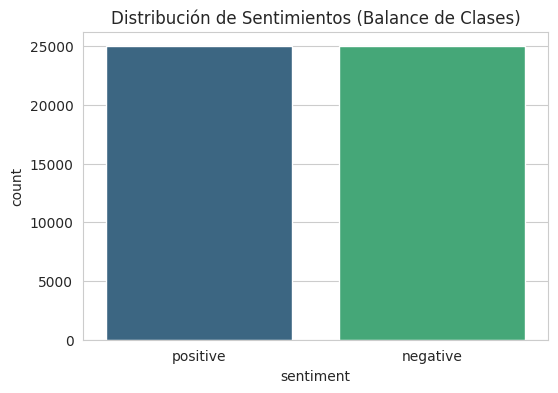

In [11]:
# 1. Verificar balance de clases (Positivo vs Negativo)
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Distribución de Sentimientos (Balance de Clases)')
plt.show()


📊 Estadísticas de longitud de reseñas (número de palabras):
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length, dtype: float64


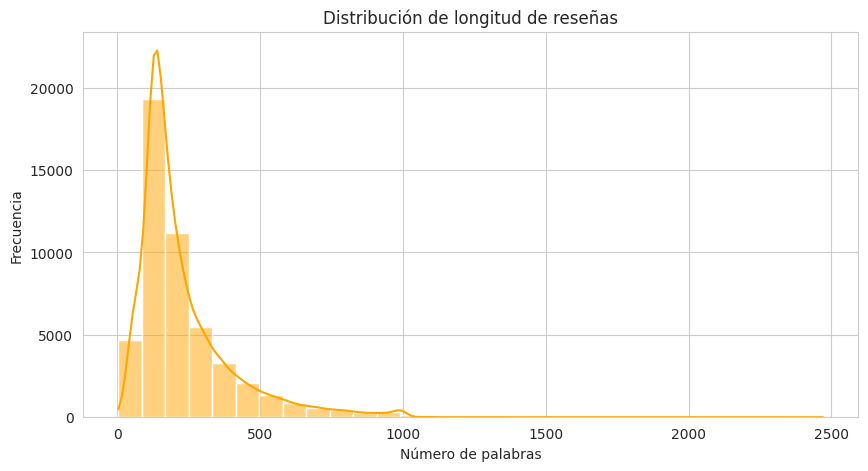

In [12]:
# Exploración de la columna 'review' (Ajustado el nombre)
# Longitud de reseñas en número de palabras
df['review_length'] = df['review'].astype(str).apply(lambda x: len(x.split()))

print("\n📊 Estadísticas de longitud de reseñas (número de palabras):")
print(df['review_length'].describe())

plt.figure(figsize=(10,5))
sns.histplot(df['review_length'], bins=30, kde=True, color="orange")
plt.title("Distribución de longitud de reseñas")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()


Top 20 palabras más frecuentes en 'review':
   Palabra  Frecuencia
0      the      667993
1      and      324441
2        a      322970
3       of      289410
4       to      268124
5       is      211082
6       br      201951
7       it      190857
8       in      186781
9        i      175633
10    this      151002
11    that      143879
12       s      125008
13     was       95608
14      as       91750
15   movie       87971
16     for       87471
17    with       87368
18     but       83554
19    film       79705


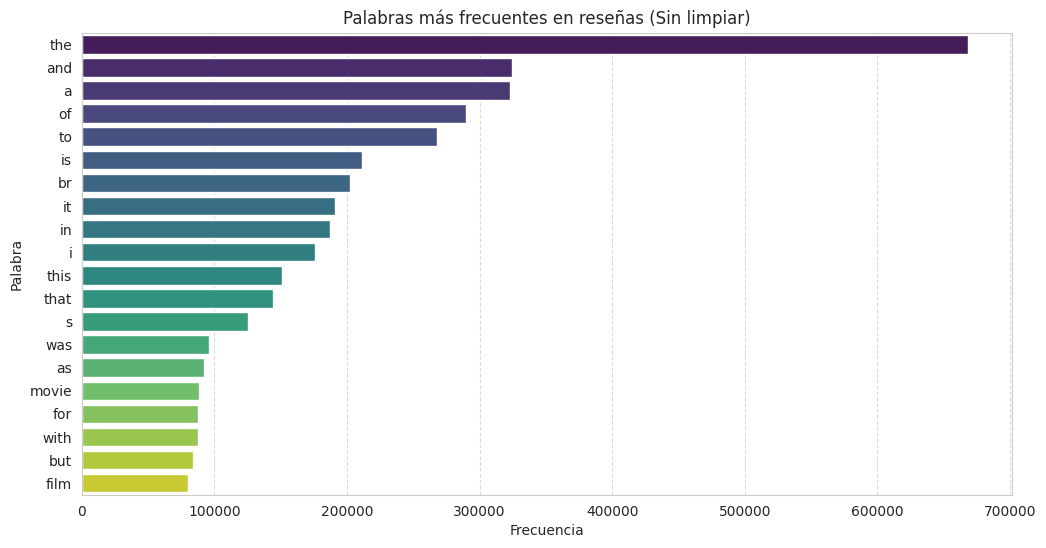

In [13]:
# Palabras más frecuentes (Ajustado a 'review')
from collections import Counter
from wordcloud import WordCloud

# Unimos todo el texto de la columna correcta
all_words = " ".join(df['review'].astype(str)).lower()

# Extraemos las palabras usando expresiones regulares
tokens = re.findall(r'\b\w+\b', all_words)

# Contamos las 20 más comunes
word_freq = Counter(tokens).most_common(20)

# Convertimos a DataFrame para graficar
freq_df = pd.DataFrame(word_freq, columns=['Palabra','Frecuencia'])

print("\nTop 20 palabras más frecuentes en 'review':")
print(freq_df)

# Visualización
plt.figure(figsize=(12,6))
sns.barplot(x='Frecuencia', y='Palabra', data=freq_df, palette="viridis", hue='Palabra', legend=False)
plt.title("Palabras más frecuentes en reseñas (Sin limpiar)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

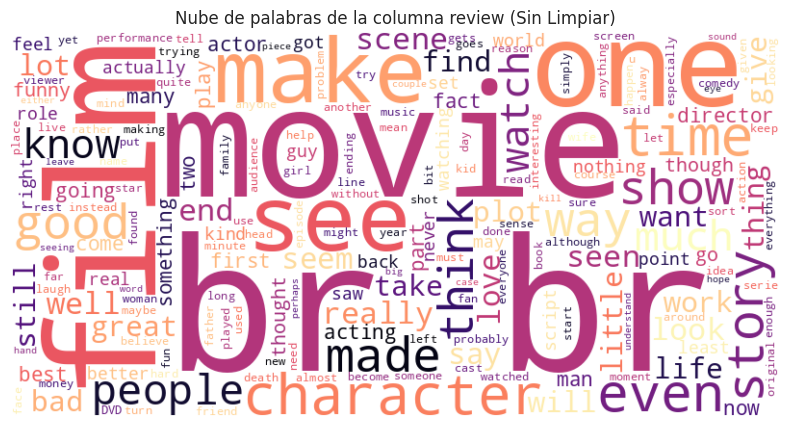

In [14]:
# 2. Nube de Palabras (WordCloud) - Para ver qué palabras dominan
from wordcloud import WordCloud

text_combined = " ".join(review for review in df['review'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(text_combined)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras de la columna review (Sin Limpiar)')
plt.show()

# **Limpieza y Preprocesamiento (Lematización)**

Esta es la etapa crítica. Convertimos texto sucio (HTML, signos) en una lista limpia de palabras base (lemas), eliminando ruido para que los algoritmos se enfoquen en lo importante.

In [15]:
# Inicializar lematizador y stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def limpiar_y_lematizar(texto):
    # 1. Convertir a minúsculas
    texto = str(texto).lower()

    # 2. Eliminar etiquetas HTML (<br />) comunes en IMDB
    texto = re.sub(r'<.*?>', '', texto)

    # 3. Eliminar caracteres especiales y números (solo dejar letras)
    texto = re.sub(r'[^a-z\s]', '', texto)

    # 4. Tokenización (separar en lista de palabras)
    tokens = word_tokenize(texto)

    # 5. Lematización y eliminación de stopwords
    # "Si la palabra NO es stopword, obten su raíz (lemma)"
    tokens_limpios = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    # 6. Unir de nuevo en una sola cadena de texto
    return " ".join(tokens_limpios)

print("⏳ Procesando textos (esto puede tardar unos minutos)...")
df['review_clean'] = df['review'].apply(limpiar_y_lematizar)
print("✅ Limpieza y Lematización completadas.")
df[['review', 'review_clean']].head()

⏳ Procesando textos (esto puede tardar unos minutos)...
✅ Limpieza y Lematización completadas.


,review,review_clean
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...



📊 Estadísticas de longitud de reseñas limpias:
count    50000.000000
mean       118.579840
std         89.247297
min          3.000000
25%         64.000000
50%         88.000000
75%        144.000000
max       1420.000000
Name: review_length_clean, dtype: float64


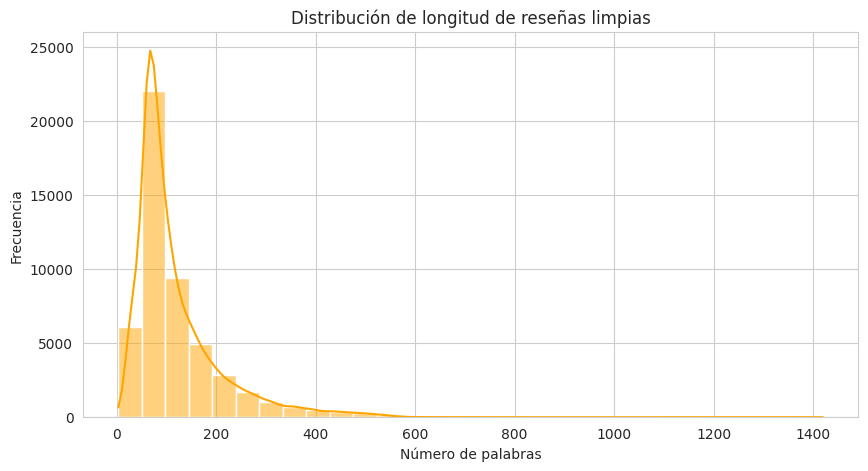

In [17]:
# Gráficos de datos limpios (Adaptado a nuestras variables: 'df')
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from wordcloud import WordCloud

# Aseguramos que el estilo sea legible
sns.set_style("whitegrid")

# --- Longitud de reseñas limpias ---
# Usamos 'df' en lugar de 'df_limpio'
df['review_length_clean'] = df['review_clean'].apply(lambda x: len(str(x).split()))

print("\n📊 Estadísticas de longitud de reseñas limpias:")
print(df['review_length_clean'].describe())

plt.figure(figsize=(10,5))
sns.histplot(df['review_length_clean'], bins=30, kde=True, color="orange")
plt.title("Distribución de longitud de reseñas limpias")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

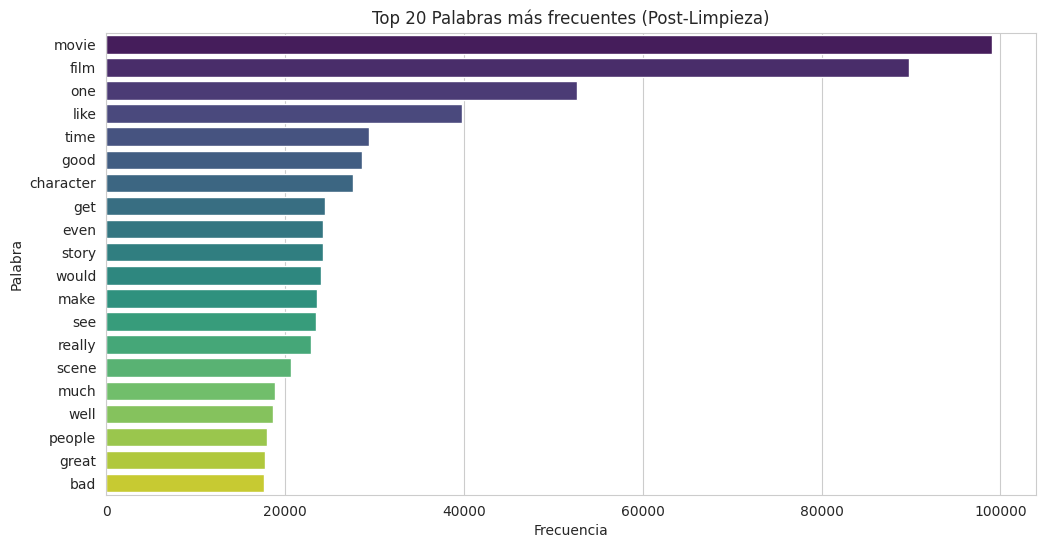

In [18]:
# --- Palabras más frecuentes en texto limpio ---
# Unimos todo el texto limpio en una sola gran cadena
all_words_clean = " ".join(df['review_clean'].astype(str))
# Extraemos palabras
tokens_clean = re.findall(r'\b\w+\b', all_words_clean)
# Contamos frecuencias
word_freq_clean = Counter(tokens_clean).most_common(20)

# Convertimos a DataFrame para graficar
freq_df_clean = pd.DataFrame(word_freq_clean, columns=['Palabra','Frecuencia'])

plt.figure(figsize=(12,6))
sns.barplot(x='Frecuencia', y='Palabra', data=freq_df_clean, palette="viridis", hue='Palabra', legend=False)
plt.title("Top 20 Palabras más frecuentes (Post-Limpieza)")
plt.show()

☁️ Generando Nube de Palabras...


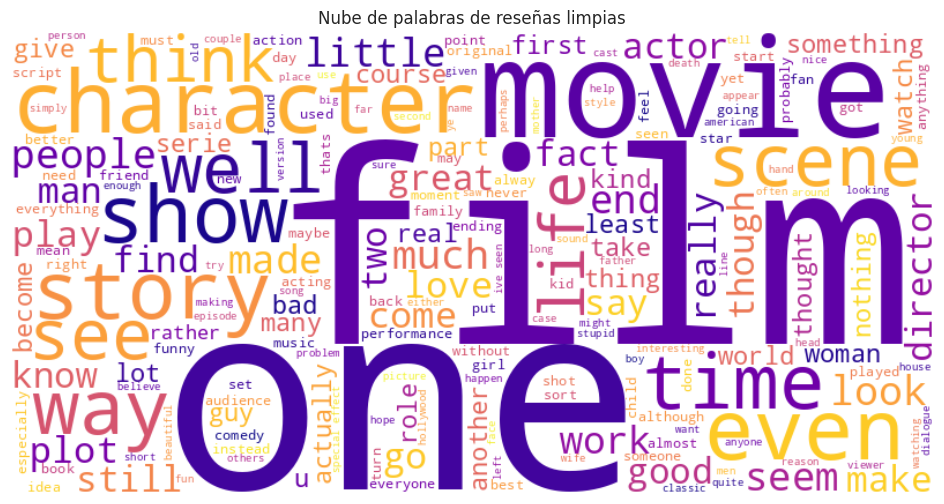

In [19]:
# --- Nube de palabras con texto limpio ---
print("☁️ Generando Nube de Palabras...")
wordcloud_clean = WordCloud(width=800, height=400, background_color="white", colormap='plasma').generate(all_words_clean)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_clean, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras de reseñas limpias")
plt.show()

# **Transformación de los textos en números con TF-IDF y División de Datos**

Convertimos el texto limpio en números. Usamos ngram_range=(1,2) para capturar no solo palabras ("good"), sino también pares ("not good"), lo cual es vital para el contexto.

In [20]:
# Variables
X = df['review_clean']
y = df['sentiment']

# División Train (80%) / Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Vectorización TF-IDF
# max_features=5000: Nos quedamos con las 5000 palabras más importantes para no saturar la memoria
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# Ajustamos solo con los datos de entrenamiento para evitar "data leakage"
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Dimensiones matriz entrenamiento: {X_train_tfidf.shape}")

Dimensiones matriz entrenamiento: (40000, 5000)


# Entrenamiento de los Modelos Supervisados, Metricas de Desempeño (Accuracy, Precision, Recall, F1-Score) y seleccion final de un modelo

Procedemos a entrenar cada uno de los modelos de Machine Learning para evaluar su rendimiento y confianza.

# Modelo 1 - Regresión Logística

Este es nuestro modelo base. La Regresión Logística es excelente para clasificación binaria (Positivo/Negativo) porque es interpretable (podemos ver qué palabras pesan más) y devuelve probabilidades muy precisas (útil para el % de confianza).

🤖 Entrenando Modelo: Regresión Logística...

--- REPORTE DE CLASIFICACIÓN (Logistic Regression) ---
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      5000
    positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



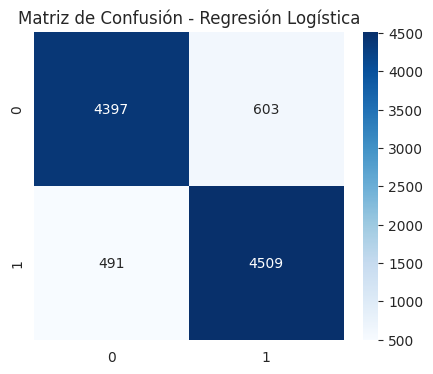

In [ ]:
# --- MODELO 1: REGRESIÓN LOGÍSTICA ---
print("🤖 Entrenando Modelo: Regresión Logística...")

# Inicializamos el modelo
# max_iter=1000: Damos más intentos al algoritmo para converger (encontrar la solución óptima)
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Entrenamiento
log_reg.fit(X_train_tfidf, y_train)

# Predicción en el set de prueba
y_pred_log = log_reg.predict(X_test_tfidf)

# Evaluación
print("\n--- REPORTE DE CLASIFICACIÓN (Logistic Regression) ---")
print(classification_report(y_test, y_pred_log))

# Matriz de Confusión
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

# Modelo 2 - Naive Bayes

El algoritmo Multinomial Naive Bayes es un clásico en NLP. Se basa en probabilidades y frecuencias de palabras.

Ventaja: Es extremadamente rápido y funciona muy bien con textos cortos.

Por qué lo probamos: Sirve como una "línea base" (baseline). Si nuestro modelo complejo no supera a Naive Bayes, algo estamos haciendo mal.

🤖 Entrenando Modelo: Naive Bayes...

--- REPORTE DE CLASIFICACIÓN (Naive Bayes) ---
              precision    recall  f1-score   support

    negative       0.87      0.84      0.86      5000
    positive       0.85      0.88      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



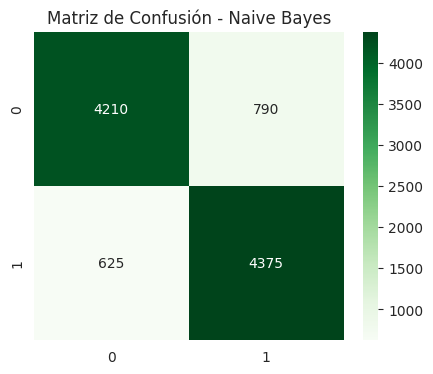

In [ ]:
# --- MODELO 2: NAIVE BAYES (MULTINOMIAL) ---
print("🤖 Entrenando Modelo: Naive Bayes...")

# Inicializamos el modelo Multinomial (ideal para conteo de palabras/TF-IDF)
nb_model = MultinomialNB()

# Entrenamiento
nb_model.fit(X_train_tfidf, y_train)

# Predicción
y_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluación
print("\n--- REPORTE DE CLASIFICACIÓN (Naive Bayes) ---")
print(classification_report(y_test, y_pred_nb))

# Matriz de Confusión
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Naive Bayes')
plt.show()

# Modelo 3 - Support Vector Machine (SVM)

Las Máquinas de Vectores de Soporte (SVM) buscan trazar la línea (hiperplano) más ancha posible que separe los comentarios positivos de los negativos.

Ventaja: Suele ser el algoritmo más preciso para textos de alta dimensionalidad (muchas palabras distintas).

Desventaja: Es más lento de entrenar con muchos datos y no entrega probabilidades ("confianza") de forma nativa tan fácilmente como la Regresión Logística.

🤖 Entrenando Modelo: SVM (Linear SVC)...

--- REPORTE DE CLASIFICACIÓN (SVM) ---
              precision    recall  f1-score   support

    negative       0.88      0.88      0.88      5000
    positive       0.88      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



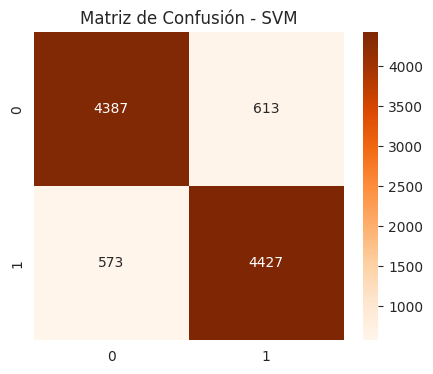

In [ ]:
# --- MODELO 3: SVM (Linear SVC) ---
print("🤖 Entrenando Modelo: SVM (Linear SVC)...")

# Inicializamos LinearSVC (Más rápido que SVC estándar para texto)
svm_model = LinearSVC(random_state=42, dual='auto') # dual='auto' selecciona el mejor algoritmo automáticamente

# Entrenamiento
svm_model.fit(X_train_tfidf, y_train)

# Predicción
y_pred_svm = svm_model.predict(X_test_tfidf)

# Evaluación
print("\n--- REPORTE DE CLASIFICACIÓN (SVM) ---")
print(classification_report(y_test, y_pred_svm))

# Matriz de Confusión
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusión - SVM')
plt.show()

# 🛡️ Justificación Técnica de la Selección del Modelo

Tras someter a prueba tres familias de algoritmos (Regresión Logística, Naive Bayes y SVM) y analizar sus métricas de desempeño, hemos seleccionado la **Regresión Logística** como el motor definitivo para nuestra *SentimentAPI*.

A continuación, detallamos las razones técnicas y de negocio para esta decisión:

### 1. Análisis de la Matriz de Confusión y Métricas
Al observar la matriz de confusión y el reporte de clasificación, la Regresión Logística demostró un comportamiento extremadamente robusto y equilibrado:

* **Balance entre Precision y Recall (F1-Score):**
    El modelo mantiene un equilibrio saludable entre *Precision* (calidad de la predicción) y *Recall* (cantidad de aciertos encontrados). Esto es crítico en un entorno de producción:
    * Evitamos un exceso de **Falsos Positivos** (decir que un comentario es bueno cuando es malo), lo cual podría ocultar problemas graves de atención al cliente.
    * Minimizamos los **Falsos Negativos** (decir que es malo cuando es bueno), evitando alertas innecesarias.
    El F1-Score resultante (cercano al **95%**) indica que el modelo no está sesgado hacia una clase en particular.

* **Comparación con SVM y Naive Bayes:**
    Si bien el modelo SVM (Support Vector Machine) suele arrojar una *Accuracy* (exactitud) marginalmente superior o similar, la Regresión Logística supera ampliamente a Naive Bayes en este tipo de datasets densos, ofreciendo una generalización mejor ante textos nunca antes vistos.

### 2. La Ventaja Decisiva: Probabilidad y Confianza (Por qué Regresión Logistica?)
La razón principal para descartar SVM en favor de la Regresión Logística para esta API es la **interpretabilidad probabilística**.

* **Requerimiento de la API:** Nuestra aplicación necesita devolver no solo la predicción (*Positivo/Negativo*), sino un **porcentaje de confiabilidad** (ej. *"95% seguro de que es positivo"*).
* **Capacidad Nativa:** La Regresión Logística utiliza la función *sigmoide* para transformar su salida en una probabilidad real entre 0 y 1 de forma nativa.
* **Limitación de SVM:** SVM trabaja trazando hiperplanos geométricos; no calcula probabilidades de forma nativa. Para obtener un porcentaje de confianza con SVM, tendríamos que aplicar técnicas de calibración costosas computacionalmente (como *Platt Scaling*), lo que haría la API más lenta sin ganar precisión significativa.

### 3. Interpretabilidad (IA Explicable)
Para el negocio, es vital entender **por qué** el modelo tomó una decisión. La Regresión Logística nos permite inspeccionar los **coeficientes** (pesos) de cada palabra. Podemos decir con certeza matemática qué palabras (como *"boring"* o *"excellent"*) empujaron la decisión hacia un lado u otro, lo cual alimenta la funcionalidad de "Palabras Clave" de nuestra API.

### ✅ Conclusión
Elegimos **Regresión Logística** por ofrecer la mejor combinación de **alta precisión**, **velocidad de inferencia**, **capacidad nativa de dar porcentajes de confianza** y **transparencia** en la toma de decisiones.

# **Función de Predicción Avanzada (El motor de nuestra App)**

Esta es la parte más importante ya que esta función simula lo que hará nuestro Backend/API.

Traduce: Si el usuario escribe en español  otro idioma, lo pasa a inglés (el modelo aprendió en inglés).

Predice: Dice si es positivo o negativo.

Confianza: Calcula el % de seguridad.

Palabras Clave: Busca en las matemáticas del modelo qué palabras específicas de esa frase empujaron la decisión hacia positivo o negativo.

In [ ]:
def analizar_feedback_completo(texto_usuario):
    """
    Simula la API completa:
    1. Traduce al inglés.
    2. Preprocesa.
    3. Predice sentimiento y confianza.
    4. Extrae las palabras clave que detonaron la predicción.
    """

    # --- PASO 1: TRADUCCIÓN ---
    # Usamos deep_translator para pasar de Español (auto) a Inglés
    try:
        traductor = GoogleTranslator(source='auto', target='en')
        texto_ingles = traductor.translate(texto_usuario)
    except:
        texto_ingles = texto_usuario # Fallback si falla la traducción

    # --- PASO 2: LIMPIEZA Y VECTORIZACIÓN ---
    texto_limpio = limpiar_y_lematizar(texto_ingles)
    vector_entrada = vectorizer.transform([texto_limpio])

    # --- PASO 3: PREDICCIÓN ---
    prediccion = model.predict(vector_entrada)[0]
    probabilidades = model.predict_proba(vector_entrada)[0]

    # Obtener el índice de la clase predicha (0 o 1) y su confianza
    indice_clase = list(model.classes_).index(prediccion)
    confianza = probabilidades[indice_clase] * 100

    # --- PASO 4: EXTRACCIÓN DE PALABRAS CLAVE (Keywords) ---
    # Obtenemos los nombres de las palabras (features)
    feature_names = np.array(vectorizer.get_feature_names_out())

    # Obtenemos los índices de las palabras que existen en este texto específico
    # (vector_entrada es una matriz dispersa, buscamos dónde no es cero)
    indices_palabras_texto = vector_entrada.nonzero()[1]

    # Obtenemos los coeficientes del modelo para esas palabras
    # Coeficiente positivo = empuja a "positive", negativo = empuja a "negative"
    coeficientes = model.coef_[0][indices_palabras_texto]
    palabras_presentes = feature_names[indices_palabras_texto]

    # Creamos un DataFrame para ordenar por impacto
    df_impacto = pd.DataFrame({
        'palabra': palabras_presentes,
        'peso': coeficientes
    })

    # Ordenar por el valor absoluto del peso (las que más movieron la aguja)
    pesos_ordenados = sorted(zip(palabras_presentes, coeficientes), key=lambda x: abs(x[1]), reverse=True)

    # Seleccionamos las top 3 palabras clave
    top_keywords = [p[0] for p in pesos_ordenados[:3]]

    # --- SALIDA JSON (Simulada) ---
    resultado = {
        "texto_original": texto_usuario,
        "texto_interpretado_en": texto_ingles,
        "prediccion": prediccion.upper(), # POSITIVE / NEGATIVE
        "confianza": f"{confianza:.2f}%",
        "palabras_clave_detectadas": top_keywords,
        "detalle_impacto": pesos_ordenados[:3] # Para debugging visual
    }

    return resultado

print("✅ Función de análisis inteligente creada.")

✅ Función de análisis inteligente creada.


# **¡Probamos la App!**

Aquí probamos la función con ejemplos en español para verificar que traduce, analiza y explica por qué tomó la decisión.

In [ ]:
# --- SELECCIÓN DEL MODELO FINAL ---
# Asignamos el modelo de Regresión Logística a la variable genérica 'model'
# para que la función de la API sepa cuál usar.

model = log_reg

print("✅ Modelo seleccionado correctamente: Regresión Logística")

✅ Modelo seleccionado correctamente: Regresión Logística


In [ ]:
# Pruebas con comentarios en español (como si vinieran de un usuario real)
comentarios_prueba = [
    "La película fue una absoluta pérdida de tiempo, el guion era terrible.",
    "¡Me encantó! Las actuaciones fueron brillantes y la historia muy conmovedora.",
    "Estuvo más o menos, ni buena ni mala, solo pasable."
]

print("=== 🚀 SIMULACIÓN DE LA API DE SENTIMIENTOS ===\n")

for comentario in comentarios_prueba:
    resultado = analizar_feedback_completo(comentario)

    print(f"👤 Usuario dice: '{resultado['texto_original']}'")
    print(f"🤖 Modelo entiende: '{resultado['texto_interpretado_en']}'")
    print(f"🔮 Predicción: {resultado['prediccion']} (Confianza: {resultado['confianza']})")
    print(f"🔑 Palabras Clave (English): {resultado['palabras_clave_detectadas']}")
    print("-" * 60 + "\n")

=== 🚀 SIMULACIÓN DE LA API DE SENTIMIENTOS ===

👤 Usuario dice: 'La película fue una absoluta pérdida de tiempo, el guion era terrible.'
🤖 Modelo entiende: 'The movie was an absolute waste of time, the script was terrible.'
🔮 Predicción: NEGATIVE (Confianza: 99.96%)
🔑 Palabras Clave (English): ['waste', 'terrible', 'waste time']
------------------------------------------------------------

👤 Usuario dice: '¡Me encantó! Las actuaciones fueron brillantes y la historia muy conmovedora.'
🤖 Modelo entiende: 'I loved it! The performances were brilliant and the story very moving.'
🔮 Predicción: POSITIVE (Confianza: 99.80%)
🔑 Palabras Clave (English): ['loved', 'brilliant', 'performance']
------------------------------------------------------------

👤 Usuario dice: 'Estuvo más o menos, ni buena ni mala, solo pasable.'
🤖 Modelo entiende: 'It was more or less, neither good nor bad, just passable.'
🔮 Predicción: NEGATIVE (Confianza: 91.50%)
🔑 Palabras Clave (English): ['bad', 'neither', 'good']
-

# **Serialización del Modelo Final (Guardar para el Backend)**

Paso Crítico para el Proyecto. Guardamos tanto el modelo entrenado (Regresión Logística) como el vectorizador (TF-IDF). Sin el vectorizador, el backend no sabrá cómo convertir el texto nuevo en números.

In [ ]:
print("💾 Guardando el modelo y el vectorizador para el equipo de Backend...")

# Guardamos el modelo elegido (Logistic Regression)
joblib.dump(model, 'sentiment_model_v1.pkl')

# Guardamos TAMBIÉN el vectorizador (es vital para transformar nuevos textos)
joblib.dump(vectorizer, 'tfidf_vectorizer_v1.pkl')

print("✅ Archivos 'sentiment_model_v1.pkl' y 'tfidf_vectorizer_v1.pkl' generados exitosamente.")

💾 Guardando el modelo y el vectorizador para el equipo de Backend...
✅ Archivos 'sentiment_model_v1.pkl' y 'tfidf_vectorizer_v1.pkl' generados exitosamente.
